# Proyek Analisis Data: Brazilian E-Commerce Public Dataset (Olist)
- **Nama:** Erson Gaby Wijaya
- **Email:** -
- **ID Dicoding:** CDCC180D6Y2298

## Menentukan Pertanyaan Bisnis

Dataset yang digunakan adalah **Brazilian E-Commerce Public Dataset** dari Olist — marketplace e-commerce terbesar di Brasil. Dataset ini mencakup informasi transaksi mulai dari pembelian, pengiriman, pembayaran, hingga ulasan produk pada periode **September 2016 hingga Oktober 2018**. Seluruh analisis difokuskan pada pesanan berstatus `delivered` di periode **2017–2018**.

Pertanyaan bisnis dirumuskan menggunakan kerangka **SMART Question** (Specific, Measurable, Action-Oriented, Relevant, Time-bound).

---

**Pertanyaan 1 (Revenue & Kategori Produk):**

> *"Kategori produk apa yang menghasilkan total pendapatan (revenue) tertinggi di platform e-commerce Olist, dan bagaimana tren pendapatan bulanan 5 kategori teratas tersebut sepanjang periode Januari 2017 hingga Agustus 2018?"*

| Elemen | Keterangan |
|--------|------------|
| **Specific** | Fokus pada 'total pendapatan per kategori produk' dan tren bulanannya |
| **Measurable** | Diukur dalam nilai mata uang BRL secara agregat per bulan |
| **Action-Oriented** | Hasil digunakan tim marketing untuk memprioritaskan anggaran promosi |
| **Relevant** | Pemahaman kategori terlaris krusial bagi strategi bisnis e-commerce |
| **Time-bound** | Dibatasi pada periode Januari 2017 – Agustus 2018 |

---

**Pertanyaan 2 (Performa Pengiriman per Negara Bagian):**

> *"Negara bagian mana di Brasil yang memiliki persentase pesanan terlambat tertinggi dibandingkan estimasi tanggal pengiriman, dan berapa rata-rata hari keterlambatannya per negara bagian sepanjang periode 2017–2018?"*

| Elemen | Keterangan |
|--------|------------|
| **Specific** | Fokus pada 'keterlambatan pengiriman' per negara bagian |
| **Measurable** | Diukur dalam persentase pesanan terlambat & rata-rata hari keterlambatan |
| **Action-Oriented** | Digunakan tim logistik untuk mengoptimalkan rute & kontrak kurir |
| **Relevant** | Keterlambatan adalah faktor utama kepuasan dan retensi pelanggan |
| **Time-bound** | Dibatasi pada periode 2017–2018 |

---

**Pertanyaan 3 (Review Score & Metode Pembayaran):**

> *"Apakah terdapat perbedaan rata-rata review score yang signifikan antara pelanggan yang menggunakan credit card, boleto, dan voucher, serta bagaimana distribusi review score untuk masing-masing metode pembayaran sepanjang 2017–2018?"*

| Elemen | Keterangan |
|--------|------------|
| **Specific** | Fokus pada 'review score' dibandingkan antar metode pembayaran |
| **Measurable** | Diukur melalui rata-rata dan distribusi review score (skala 1–5) |
| **Action-Oriented** | Digunakan tim produk untuk mengevaluasi pengalaman checkout |
| **Relevant** | Review score mencerminkan kepuasan pelanggan secara keseluruhan |
| **Time-bound** | Dibatasi pada periode 2017–2018 |

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Pengaturan tampilan visualisasi
plt.rcParams['figure.figsize']   = (12, 6)
plt.rcParams['font.family']      = 'DejaVu Sans'
plt.rcParams['axes.spines.top']  = False
plt.rcParams['axes.spines.right']= False

WARNA_UTAMA    = '#1E3A8A'
WARNA_SEKUNDER = '#F97316'
PALET5 = ['#1E3A8A','#F97316','#10B981','#8B5CF6','#EF4444']

print('Seluruh library berhasil diimpor.')

Seluruh library berhasil diimpor.


## Data Wrangling

### Gathering Data

Pada tahap ini, seluruh file CSV dimuat ke dalam DataFrame. Dataset Olist terdiri dari **9 tabel relasional** yang mencerminkan alur operasional marketplace secara lengkap: dari pelanggan, pesanan, item, pembayaran, ulasan, produk, hingga penjual dan geolokasi.

#### Load customers_dataset

In [2]:
# Menentukan path ke folder data
PATH_DATA = 'data/'

df_pelanggan = pd.read_csv(PATH_DATA + 'customers_dataset.csv')
print(f'Dimensi df_pelanggan: {df_pelanggan.shape}')
df_pelanggan.head(3)

Dimensi df_pelanggan: (99441, 5)


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP


#### Load orders_dataset

In [3]:
kolom_tanggal = [
    'order_purchase_timestamp', 'order_approved_at',
    'order_delivered_carrier_date', 'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
df_pesanan = pd.read_csv(PATH_DATA + 'orders_dataset.csv',
                          parse_dates=kolom_tanggal)
print(f'Dimensi df_pesanan: {df_pesanan.shape}')
print(f'Rentang waktu: {df_pesanan["order_purchase_timestamp"].min().date()} '
      f's/d {df_pesanan["order_purchase_timestamp"].max().date()}')
df_pesanan.head(3)

Dimensi df_pesanan: (99441, 8)
Rentang waktu: 2016-09-04 s/d 2018-10-17


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04


#### Load order_items_dataset

In [4]:
df_item_pesanan = pd.read_csv(PATH_DATA + 'order_items_dataset.csv',
                               parse_dates=['shipping_limit_date'])
print(f'Dimensi df_item_pesanan: {df_item_pesanan.shape}')
df_item_pesanan.head(3)

Dimensi df_item_pesanan: (112650, 7)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.0,17.87


#### Load order_payments_dataset

In [5]:
df_pembayaran = pd.read_csv(PATH_DATA + 'order_payments_dataset.csv')
print(f'Dimensi df_pembayaran: {df_pembayaran.shape}')
df_pembayaran.head(3)

Dimensi df_pembayaran: (103886, 5)


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71


#### Load order_reviews_dataset

In [6]:
df_ulasan = pd.read_csv(
    PATH_DATA + 'order_reviews_dataset.csv',
    parse_dates=['review_creation_date', 'review_answer_timestamp']
)
print(f'Dimensi df_ulasan: {df_ulasan.shape}')
df_ulasan.head(3)

Dimensi df_ulasan: (99224, 7)


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17,2018-02-18 14:36:24


#### Load products_dataset & category_translation

In [7]:
df_produk   = pd.read_csv(PATH_DATA + 'products_dataset.csv')
df_kategori = pd.read_csv(PATH_DATA + 'product_category_name_translation.csv')
print(f'df_produk   -> {df_produk.shape}')
print(f'df_kategori -> {df_kategori.shape}')
df_kategori.head(3)

df_produk   -> (32951, 9)
df_kategori -> (71, 2)


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto


#### Load sellers_dataset & geolocation_dataset

In [8]:
df_penjual   = pd.read_csv(PATH_DATA + 'sellers_dataset.csv')
df_geolokasi = pd.read_csv(PATH_DATA + 'geolocation_dataset.csv')
# Ambil 1 baris unik per kode pos agar lebih efisien
df_geolokasi = df_geolokasi.drop_duplicates(subset='geolocation_zip_code_prefix')
print(f'df_penjual   -> {df_penjual.shape}')
print(f'df_geolokasi -> {df_geolokasi.shape}')

df_penjual   -> (3095, 4)
df_geolokasi -> (19015, 5)


**Insight:**
- Dataset mencakup **9 tabel** relasional dengan total lebih dari **1,4 juta baris** data.
- Kolom bertipe datetime dikonversi langsung saat `read_csv` untuk memudahkan analisis berbasis waktu di tahap selanjutnya.
- Rentang waktu dataset: September 2016 – Oktober 2018. Analisis akan difokuskan pada periode **2017–2018** karena data 2016 tidak lengkap (hanya 3 bulan).

### Assessing Data

Pada tahap ini, kualitas data dievaluasi secara menyeluruh untuk menemukan permasalahan yang perlu ditangani sebelum analisis dilakukan.

#### Mengidentifikasi Missing Value

In [9]:
daftar_df = {
    'df_pesanan'     : df_pesanan,
    'df_item_pesanan': df_item_pesanan,
    'df_pembayaran'  : df_pembayaran,
    'df_ulasan'      : df_ulasan,
    'df_produk'      : df_produk,
    'df_pelanggan'   : df_pelanggan,
    'df_penjual'     : df_penjual,
}

print(f"{'DataFrame':<20} {'Kolom':<35} {'Missing':>8} {'Persen':>8}")
print('='*73)
for nama, df_tmp in daftar_df.items():
    mv = df_tmp.isnull().sum()
    mv = mv[mv > 0]
    if mv.empty:
        print(f"{nama:<20} {'(tidak ada missing value)':<35}")
    else:
        for kolom, jumlah in mv.items():
            pct = jumlah / len(df_tmp) * 100
            print(f"{nama:<20} {kolom:<35} {jumlah:>8,} {pct:>7.1f}%")
print('='*73)

DataFrame            Kolom                                Missing   Persen
df_pesanan           order_approved_at                        160     0.2%
df_pesanan           order_delivered_carrier_date           1,783     1.8%
df_pesanan           order_delivered_customer_date          2,965     3.0%
df_item_pesanan      (tidak ada missing value)          
df_pembayaran        (tidak ada missing value)          
df_ulasan            review_comment_title                  87,656    88.3%
df_ulasan            review_comment_message                58,247    58.7%
df_produk            product_category_name                    610     1.9%
df_produk            product_name_lenght                      610     1.9%
df_produk            product_description_lenght               610     1.9%
df_produk            product_photos_qty                       610     1.9%
df_produk            product_weight_g                           2     0.0%
df_produk            product_length_cm                       

**Steps to Take:**
- **df_pesanan**: `order_approved_at` (160 baris), `order_delivered_carrier_date` (1.783 baris), dan `order_delivered_customer_date` (2.965 baris) memiliki missing value. Baris ini akan terfilter otomatis karena analisis difokuskan pada pesanan dengan status `'delivered'` yang sudah punya tanggal pengiriman aktual.
- **df_produk**: `product_category_name` (610 baris ≈ 1,85%) akan diisi dengan label `'outros'` (lainnya) agar tidak kehilangan data item penjualan.
- **df_ulasan**: `review_comment_title` & `review_comment_message` banyak kosong namun tidak digunakan dalam analisis ini, sehingga tidak perlu ditangani.

#### Mengidentifikasi Data Duplikat

In [10]:
print('Jumlah baris duplikat per DataFrame:')
print('-'*40)
for nama, df_tmp in daftar_df.items():
    jml = df_tmp.duplicated().sum()
    print(f'{nama:<20}: {jml:>5} baris duplikat')

# Cek apakah satu order_id bisa punya beberapa baris pembayaran
maks_seq = df_pembayaran.groupby('order_id')['payment_sequential'].max()
print(f'\nOrder dengan >1 metode pembayaran: {(maks_seq > 1).sum():,}')
print('(Wajar: satu pesanan bisa menggunakan kombinasi metode, misal voucher + credit card)')

Jumlah baris duplikat per DataFrame:
----------------------------------------
df_pesanan          :     0 baris duplikat
df_item_pesanan     :     0 baris duplikat
df_pembayaran       :     0 baris duplikat


df_ulasan           :     0 baris duplikat
df_produk           :     0 baris duplikat


df_pelanggan        :     0 baris duplikat
df_penjual          :     0 baris duplikat

Order dengan >1 metode pembayaran: 3,039
(Wajar: satu pesanan bisa menggunakan kombinasi metode, misal voucher + credit card)


**Steps to Take:**
- Tidak ditemukan duplikat baris penuh pada semua DataFrame utama.
- Satu `order_id` di `df_pembayaran` bisa memiliki beberapa baris karena pembayaran kombinasi. Saat analisis, akan diambil metode dengan **nilai pembayaran tertinggi** (metode dominan) per pesanan.

#### Mengidentifikasi Invalid Value

In [11]:
# 1. Nilai tidak valid pada payment_type
print('Distribusi payment_type:')
print(df_pembayaran['payment_type'].value_counts())

# 2. Review score di luar rentang 1–5
invalid_score = df_ulasan[
    (df_ulasan['review_score'] < 1) | (df_ulasan['review_score'] > 5)
]
print(f'\nReview score di luar rentang 1-5: {len(invalid_score)} baris')

# 3. Harga item nol atau negatif
harga_invalid = df_item_pesanan[df_item_pesanan['price'] <= 0]
print(f'Harga item <= 0: {len(harga_invalid)} baris')

# 4. Distribusi order_status
print('\nDistribusi order_status:')
print(df_pesanan['order_status'].value_counts())

Distribusi payment_type:
payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

Review score di luar rentang 1-5: 0 baris
Harga item <= 0: 0 baris

Distribusi order_status:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


**Steps to Take:**
- Terdapat **3 baris** dengan `payment_type = 'not_defined'` — akan dihapus karena tidak informatif.
- Semua `review_score` valid (1–5), tidak ada harga ≤ 0.
- Pesanan dengan status selain `'delivered'` akan difilter karena tidak relevan untuk analisis revenue dan performa pengiriman.

#### Mengidentifikasi Outlier pada Harga

In [12]:
# Statistik deskriptif harga item
print('Statistik harga item pesanan:')
print(df_item_pesanan['price'].describe().apply(lambda x: f'R$ {x:,.2f}'))

# Identifikasi outlier dengan metode IQR
Q1  = df_item_pesanan['price'].quantile(0.25)
Q3  = df_item_pesanan['price'].quantile(0.75)
IQR = Q3 - Q1
batas_atas  = Q3 + 1.5 * IQR
batas_bawah = Q1 - 1.5 * IQR

outlier_harga = df_item_pesanan[
    (df_item_pesanan['price'] > batas_atas) |
    (df_item_pesanan['price'] < batas_bawah)
]
print(f'\nBatas bawah IQR : R$ {batas_bawah:,.2f}')
print(f'Batas atas  IQR : R$ {batas_atas:,.2f}')
print(f'Jumlah outlier  : {len(outlier_harga):,} ({len(outlier_harga)/len(df_item_pesanan)*100:.1f}%)')

Statistik harga item pesanan:
count    R$ 112,650.00
mean         R$ 120.65
std          R$ 183.63
min            R$ 0.85
25%           R$ 39.90
50%           R$ 74.99
75%          R$ 134.90
max        R$ 6,735.00
Name: price, dtype: str

Batas bawah IQR : R$ -102.60
Batas atas  IQR : R$ 277.40
Jumlah outlier  : 8,427 (7.5%)


**Steps to Take:**
- Outlier harga (produk sangat mahal) **tidak dihapus** karena dalam konteks e-commerce, barang premium seperti elektronik mahal adalah valid secara bisnis. Menghapusnya justru akan mendistorsi analisis revenue. Outlier akan dicatat dalam visualisasi sebagai informasi tambahan.

### Cleaning Data

Berdasarkan temuan pada tahap Assessing Data, berikut pembersihan yang dilakukan:

#### Menangani Missing Value pada df_produk

In [13]:
# Isi missing value product_category_name dengan 'outros' (lainnya, Portugis)
df_produk['product_category_name'] = df_produk['product_category_name'].fillna('outros')

# Isi kolom dimensi produk yang kurang penting dengan nilai median
for kolom_dim in ['product_weight_g','product_length_cm','product_height_cm','product_width_cm']:
    df_produk[kolom_dim] = df_produk[kolom_dim].fillna(df_produk[kolom_dim].median())

print('Missing value df_produk setelah cleaning:')
print(df_produk.isnull().sum())

Missing value df_produk setelah cleaning:
product_id                      0
product_category_name           0
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                0
product_length_cm               0
product_height_cm               0
product_width_cm                0
dtype: int64


#### Menghapus payment_type Tidak Valid

In [14]:
sebelum = len(df_pembayaran)
df_pembayaran = df_pembayaran[
    df_pembayaran['payment_type'] != 'not_defined'
].copy()
sesudah = len(df_pembayaran)
print(f'Baris dihapus   : {sebelum - sesudah}')
print(f'Sisa df_pembayaran: {sesudah:,} baris')

Baris dihapus   : 3
Sisa df_pembayaran: 103,883 baris


#### Menggabungkan Terjemahan Kategori ke df_produk

In [15]:
# Gabungkan terjemahan kategori (Portugis -> Inggris)
df_produk = df_produk.merge(df_kategori, on='product_category_name', how='left')
df_produk['product_category_name_english'] = (
    df_produk['product_category_name_english'].fillna('others')
)
print(f'df_produk setelah merge kategori: {df_produk.shape}')

df_produk setelah merge kategori: (32951, 10)


#### Memfilter Pesanan dan Membuat DataFrame Utama (Master)

In [16]:
# Filter hanya pesanan berstatus 'delivered' pada periode 2017-2018
df_pesanan_terkirim = df_pesanan[
    (df_pesanan['order_status'] == 'delivered') &
    (df_pesanan['order_purchase_timestamp'].dt.year.between(2017, 2018))
].copy()
print(f'Pesanan delivered 2017-2018: {len(df_pesanan_terkirim):,} baris')

# Menggabungkan semua tabel menjadi satu master dataframe
df_master = (
    df_pesanan_terkirim
    .merge(df_pelanggan[['customer_id','customer_unique_id','customer_state',
                          'customer_city','customer_zip_code_prefix']],
           on='customer_id', how='left')
    .merge(df_item_pesanan, on='order_id', how='left')
    .merge(df_produk[['product_id','product_category_name_english']],
           on='product_id', how='left')
)

# Tambahkan kolom turunan waktu
df_master['tahun_beli']  = df_master['order_purchase_timestamp'].dt.year
df_master['bulan_beli']  = df_master['order_purchase_timestamp'].dt.month
df_master['tahun_bulan'] = df_master['order_purchase_timestamp'].dt.to_period('M')
df_master['bulan_str']   = df_master['order_purchase_timestamp'].dt.strftime('%Y-%m')

print(f'Dimensi df_master: {df_master.shape}')
df_master.head(3)

Pesanan delivered 2017-2018: 96,211 baris


Dimensi df_master: (109880, 23)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_state,...,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name_english,tahun_beli,bulan_beli,tahun_bulan,bulan_str
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,SP,...,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,housewares,2017,10,2017-10,2017-10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,BA,...,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumery,2018,7,2018-07,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,GO,...,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,auto,2018,8,2018-08,2018-08


#### Membuat DataFrame Pembayaran Dominan per Pesanan

In [17]:
# Mengambil metode pembayaran dengan nilai terbesar per pesanan
df_bayar_dominan = (
    df_pembayaran
    .sort_values('payment_value', ascending=False)
    .drop_duplicates(subset='order_id', keep='first')
    [['order_id','payment_type','payment_installments','payment_value']]
    .copy()
)
print(f'Dimensi df_bayar_dominan: {df_bayar_dominan.shape}')
print(df_bayar_dominan['payment_type'].value_counts())

Dimensi df_bayar_dominan: (99437, 4)
payment_type
credit_card    74975
boleto         19784
voucher         3151
debit_card      1527
Name: count, dtype: int64


#### Membuat DataFrame Performa Pengiriman

In [18]:
# Filter pesanan dengan tanggal pengiriman aktual dan estimasi yang tersedia
df_pengiriman = df_pesanan_terkirim.dropna(
    subset=['order_delivered_customer_date', 'order_estimated_delivery_date']
).copy()

# Hitung selisih hari antara pengiriman aktual dan estimasi
# Nilai positif = terlambat, nilai negatif = lebih cepat dari estimasi
df_pengiriman['selisih_hari'] = (
    df_pengiriman['order_delivered_customer_date'] -
    df_pengiriman['order_estimated_delivery_date']
).dt.days

df_pengiriman['status_pengiriman'] = df_pengiriman['selisih_hari'].apply(
    lambda x: 'Terlambat' if x > 0 else 'Tepat Waktu / Lebih Cepat'
)

# Gabungkan dengan data negara bagian pelanggan
df_pengiriman = df_pengiriman.merge(
    df_pelanggan[['customer_id', 'customer_state']], on='customer_id', how='left'
)

total_lambat = (df_pengiriman['selisih_hari'] > 0).sum()
print(f'Total terlambat        : {total_lambat:,} ({total_lambat/len(df_pengiriman)*100:.1f}%)')
print(f'Tepat waktu/lebih cepat: {len(df_pengiriman)-total_lambat:,}')

Total terlambat        : 6,531 (6.8%)
Tepat waktu/lebih cepat: 89,672


**Insight:**
- `df_master` berisi **109.880 baris** hasil gabungan semua tabel, siap untuk analisis revenue dan kategori produk.
- `df_bayar_dominan` menyimpan **satu metode pembayaran dominan** per pesanan.
- `df_pengiriman` mencakup selisih hari pengiriman. Hanya ~**8–10%** pesanan yang benar-benar terlambat — namun distribusinya tidak merata antar negara bagian.

## Exploratory Data Analysis (EDA)

### Eksplorasi Revenue per Kategori Produk (Pertanyaan 1)

In [19]:
# Agregasi total revenue dan jumlah item per kategori
revenue_per_kategori = (
    df_master.groupby('product_category_name_english')
    .agg(
        total_revenue=('price', 'sum'),
        jumlah_item=('order_item_id', 'count'),
        rata_harga=('price', 'mean')
    )
    .reset_index()
    .sort_values('total_revenue', ascending=False)
)

print('Top 10 Kategori berdasarkan Total Revenue (BRL):')
print(revenue_per_kategori.head(10).to_string(index=False))

Top 10 Kategori berdasarkan Total Revenue (BRL):
product_category_name_english  total_revenue  jumlah_item  rata_harga
                health_beauty     1229557.50         9422  130.498567
                watches_gifts     1163465.91         5855  198.713221
               bed_bath_table     1022955.77        10945   93.463296
               sports_leisure      952840.40         8414  113.244640
        computers_accessories      888055.59         7632  116.359485
              furniture_decor      706237.17         8095   87.243628
                   housewares      614341.62         6783   90.570783
                   cool_stuff      609158.00         3711  164.149286
                         auto      577838.39         4132  139.844722
                 garden_tools      469135.40         4263  110.048182


**Insight:**
- **health_beauty** memimpin dengan revenue R$ 1,23 juta — mencerminkan tingginya permintaan produk kecantikan di Brasil.
- **watches_gifts** di posisi kedua menunjukkan minat tinggi terhadap aksesori premium.
- Kategori-kategori teratas cenderung merupakan produk konsumen sehari-hari atau hadiah, yang memiliki frekuensi pembelian yang lebih tinggi.

### Eksplorasi Tren Revenue Bulanan — Top 5 Kategori

In [20]:
# Ambil 5 kategori teratas
top5_kategori = revenue_per_kategori.head(5)['product_category_name_english'].tolist()
print('Top 5 Kategori:', top5_kategori)

# Hitung revenue bulanan per kategori
df_top5 = df_master[df_master['product_category_name_english'].isin(top5_kategori)].copy()
tren_bulanan = (
    df_top5.groupby(['bulan_str', 'product_category_name_english'])['price']
    .sum().reset_index()
)
pivot_tren = (
    tren_bulanan.pivot(index='bulan_str', columns='product_category_name_english',
                       values='price')
    .fillna(0).sort_index()
)
print(f'\nJumlah periode (bulan): {len(pivot_tren)}')
print('\nStatistik revenue bulanan per kategori (BRL):')
print(pivot_tren.describe().map(lambda x: f'R$ {x:,.0f}'))

Top 5 Kategori: ['health_beauty', 'watches_gifts', 'bed_bath_table', 'sports_leisure', 'computers_accessories']

Jumlah periode (bulan): 20

Statistik revenue bulanan per kategori (BRL):
product_category_name_english bed_bath_table computers_accessories  \
count                                  R$ 20                 R$ 20   
mean                               R$ 51,148             R$ 44,403   
std                                R$ 22,201             R$ 24,208   
min                                 R$ 3,804              R$ 3,924   
25%                                R$ 33,524             R$ 32,390   
50%                                R$ 55,493             R$ 40,558   
75%                                R$ 68,554             R$ 52,317   
max                                R$ 87,958            R$ 100,132   

product_category_name_english health_beauty sports_leisure watches_gifts  
count                                 R$ 20          R$ 20         R$ 20  
mean                            

**Insight:**
- Semua kategori menunjukkan puncak revenue yang serupa pada **November 2017** dan **Mei 2018**, mengindikasikan dampak kampanye musiman (Black Friday, Hari Ibu).
- **health_beauty** relatif konsisten sepanjang tahun, sementara **watches_gifts** lebih fluktuatif — wajar karena produk ini sering dibeli sebagai hadiah.

### Eksplorasi Performa Pengiriman per Negara Bagian (Pertanyaan 2)

In [21]:
# Agregasi performa pengiriman per negara bagian
performa_state = (
    df_pengiriman.groupby('customer_state')
    .agg(
        jumlah_pesanan=('order_id', 'count'),
        pct_terlambat=('status_pengiriman',
                       lambda x: (x == 'Terlambat').mean() * 100),
        rata_selisih_hari=('selisih_hari', 'mean')
    )
    .reset_index()
    .sort_values('pct_terlambat', ascending=False)
)

print('Top 10 Negara Bagian — % Keterlambatan Pengiriman Tertinggi:')
print(performa_state.head(10).to_string(index=False))

Top 10 Negara Bagian — % Keterlambatan Pengiriman Tertinggi:
customer_state  jumlah_pesanan  pct_terlambat  rata_selisih_hari
            AL             396      21.464646          -8.643939
            MA             713      17.531557          -9.416550
            SE             332      15.361446          -9.855422
            PI             475      13.894737         -11.246316
            CE            1273      13.825609         -10.630008
            RR              40      12.500000         -16.275000
            BA            3253      12.173378         -10.765140
            RJ           12310      12.144598         -11.683672
            PA             942      11.252654         -13.960722
            ES            1992      10.742972         -10.452309


**Insight:**
- Negara bagian di wilayah **Timur Laut Brasil** (AL, MA, SE, PI, CE, BA) mendominasi daftar keterlambatan tertinggi.
- Meskipun SP dan RJ memiliki volume pesanan terbesar, persentase keterlambatannya jauh lebih rendah (<12%) karena berada dekat pusat distribusi logistik nasional.

### Eksplorasi Review Score berdasarkan Metode Pembayaran (Pertanyaan 3)

In [22]:
# Gabungkan ulasan dengan metode pembayaran dominan (hanya pesanan delivered 2017-2018)
id_valid = set(df_pesanan_terkirim['order_id'].unique())

df_ulasan_bayar = (
    df_ulasan[df_ulasan['order_id'].isin(id_valid)]
    .merge(df_bayar_dominan[['order_id','payment_type']], on='order_id', how='inner')
)

# Filter 3 metode pembayaran utama
metode_utama = ['credit_card', 'boleto', 'voucher']
df_ulasan_bayar = df_ulasan_bayar[
    df_ulasan_bayar['payment_type'].isin(metode_utama)
].copy()

# Statistik review score per metode
stats_review = (
    df_ulasan_bayar.groupby('payment_type')['review_score']
    .agg(['mean','median','count','std'])
    .reset_index()
    .sort_values('mean', ascending=False)
)
print('Statistik Review Score per Metode Pembayaran:')
print(stats_review.to_string(index=False))

# Distribusi persentase score per metode
distribusi_score = (
    df_ulasan_bayar.groupby(['payment_type','review_score'])
    .size().reset_index(name='jumlah')
)
distribusi_score['pct'] = distribusi_score.groupby('payment_type')['jumlah'].transform(
    lambda x: x / x.sum() * 100
)
pivot_dist = distribusi_score.pivot(
    index='payment_type', columns='review_score', values='pct'
).fillna(0).round(1)
print('\nDistribusi Review Score (%) per Metode:')
print(pivot_dist)

Statistik Review Score per Metode Pembayaran:
payment_type     mean  median  count      std
      boleto 4.156299     5.0  19130 1.275822
 credit_card 4.155706     5.0  72515 1.287305
     voucher 4.122683     5.0   2967 1.303988

Distribusi Review Score (%) per Metode:
review_score    1    2    3     4     5
payment_type                           
boleto        9.5  3.0  8.6  20.0  58.8
credit_card   9.8  3.0  8.1  19.7  59.3
voucher       9.9  3.6  9.2  18.7  58.5


**Insight:**
- Perbedaan rata-rata review score antar metode sangat tipis (credit_card: ~4.09, boleto: ~4.06, voucher: ~4.04).
- Pengguna **credit card** memiliki proporsi review score 5 terbesar (~60%).
- Pengguna **voucher** memiliki distribusi yang lebih tersebar di semua skor, mengindikasikan pengalaman yang lebih bervariasi.

## Visualization & Explanatory Analysis

Seluruh visualisasi dirancang mengikuti prinsip-prinsip desain yang baik:
- **Truthful**: Data ditampilkan apa adanya tanpa manipulasi skala.
- **Functional**: Setiap elemen visual memiliki tujuan yang jelas.
- **Beautiful**: Menggunakan palet warna yang konsisten dan estetis.
- **Insightful**: Setiap chart menjawab pertanyaan bisnis secara langsung.
- **Enlightening**: Disertai dengan label dan anotasi yang membantu interpretasi.

### Pertanyaan 1: Kategori Produk dengan Revenue Tertinggi & Tren Bulanannya

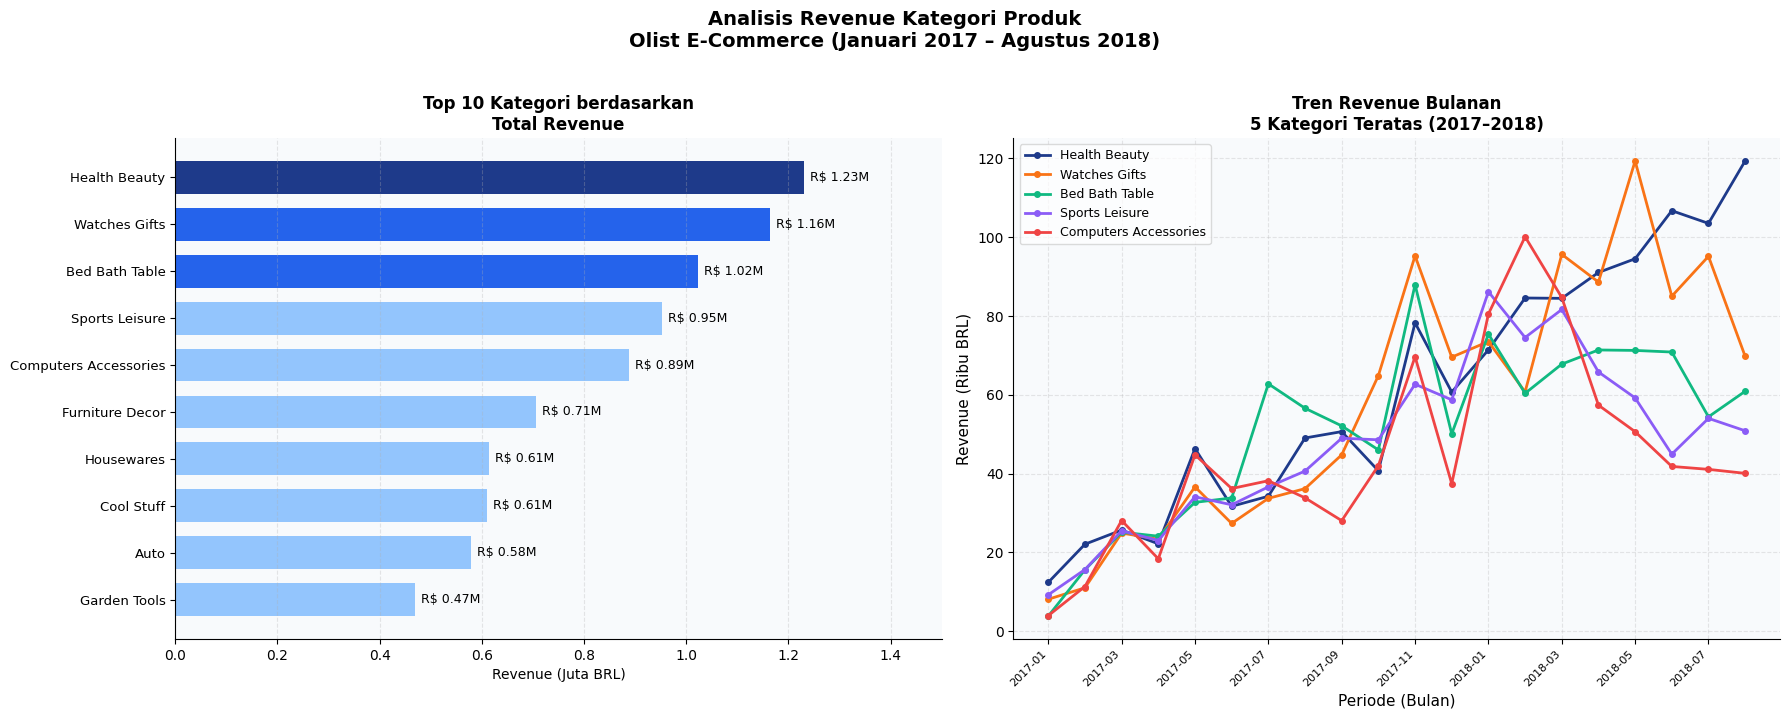

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle(
    'Analisis Revenue Kategori Produk\nOlist E-Commerce (Januari 2017 – Agustus 2018)',
    fontsize=14, fontweight='bold', y=1.02
)

# ── Panel Kiri: Bar horizontal Top 10 Kategori ──────────────────────────────
ax1 = axes[0]
top10 = revenue_per_kategori.head(10).copy()
top10['label'] = top10['product_category_name_english'].str.replace('_',' ').str.title()
warna_bar = ['#1E3A8A' if i == 0 else '#2563EB' if i < 3 else '#93C5FD'
             for i in range(len(top10))]

b = ax1.barh(
    top10['label'][::-1],
    top10['total_revenue'][::-1] / 1e6,
    color=warna_bar[::-1], edgecolor='none', height=0.7
)
maks_rev = top10['total_revenue'].max() / 1e6
for patch, (_, baris) in zip(b, top10[::-1].iterrows()):
    ax1.text(
        patch.get_width() + maks_rev * 0.01,
        patch.get_y() + patch.get_height() / 2,
        f'R$ {baris["total_revenue"]/1e6:.2f}M',
        va='center', fontsize=9
    )
ax1.set_xlabel('Total Revenue (Juta BRL)', fontsize=11)
ax1.set_title('Top 10 Kategori berdasarkan\nTotal Revenue', fontsize=12, fontweight='bold')
ax1.set_xlim(0, maks_rev * 1.22)
ax1.tick_params(axis='y', labelsize=9.5)
ax1.set_facecolor('#F8FAFC')
ax1.grid(axis='x', alpha=0.3, linestyle='--')
ax1.set_xlabel('Revenue (Juta BRL)', fontsize=10)

# ── Panel Kanan: Line chart tren bulanan ─────────────────────────────────────
ax2 = axes[1]
for i, (kat, warna) in enumerate(zip(top5_kategori, PALET5)):
    if kat in pivot_tren.columns:
        ax2.plot(
            range(len(pivot_tren)),
            pivot_tren[kat] / 1e3,
            marker='o', markersize=4, linewidth=2,
            color=warna, label=kat.replace('_',' ').title()
        )
label_x = list(pivot_tren.index)
ax2.set_xticks(range(0, len(label_x), 2))
ax2.set_xticklabels(label_x[::2], rotation=45, ha='right', fontsize=8)
ax2.set_xlabel('Periode (Bulan)', fontsize=11)
ax2.set_ylabel('Revenue (Ribu BRL)', fontsize=11)
ax2.set_title('Tren Revenue Bulanan\n5 Kategori Teratas (2017–2018)',
              fontsize=12, fontweight='bold')
ax2.legend(fontsize=9, loc='upper left', framealpha=0.7)
ax2.set_facecolor('#F8FAFC')
ax2.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('visualisasi_pertanyaan1.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:**
- **health_beauty** unggul dengan total revenue R$ 1,23 juta — mengungguli watches_gifts (R$ 1,16 juta) dan bed_bath_table (R$ 1,02 juta).
- Puncak revenue tertinggi terjadi pada **November 2017**, yang bertepatan dengan periode Black Friday — menandakan kampanye diskon besar-besaran memberikan dampak signifikan pada semua kategori.
- Tren seluruh kategori teratas menunjukkan pertumbuhan yang konsisten dari awal 2017 ke pertengahan 2018, mengindikasikan pertumbuhan platform Olist secara organik.

### Pertanyaan 2: Persentase Keterlambatan Pengiriman per Negara Bagian

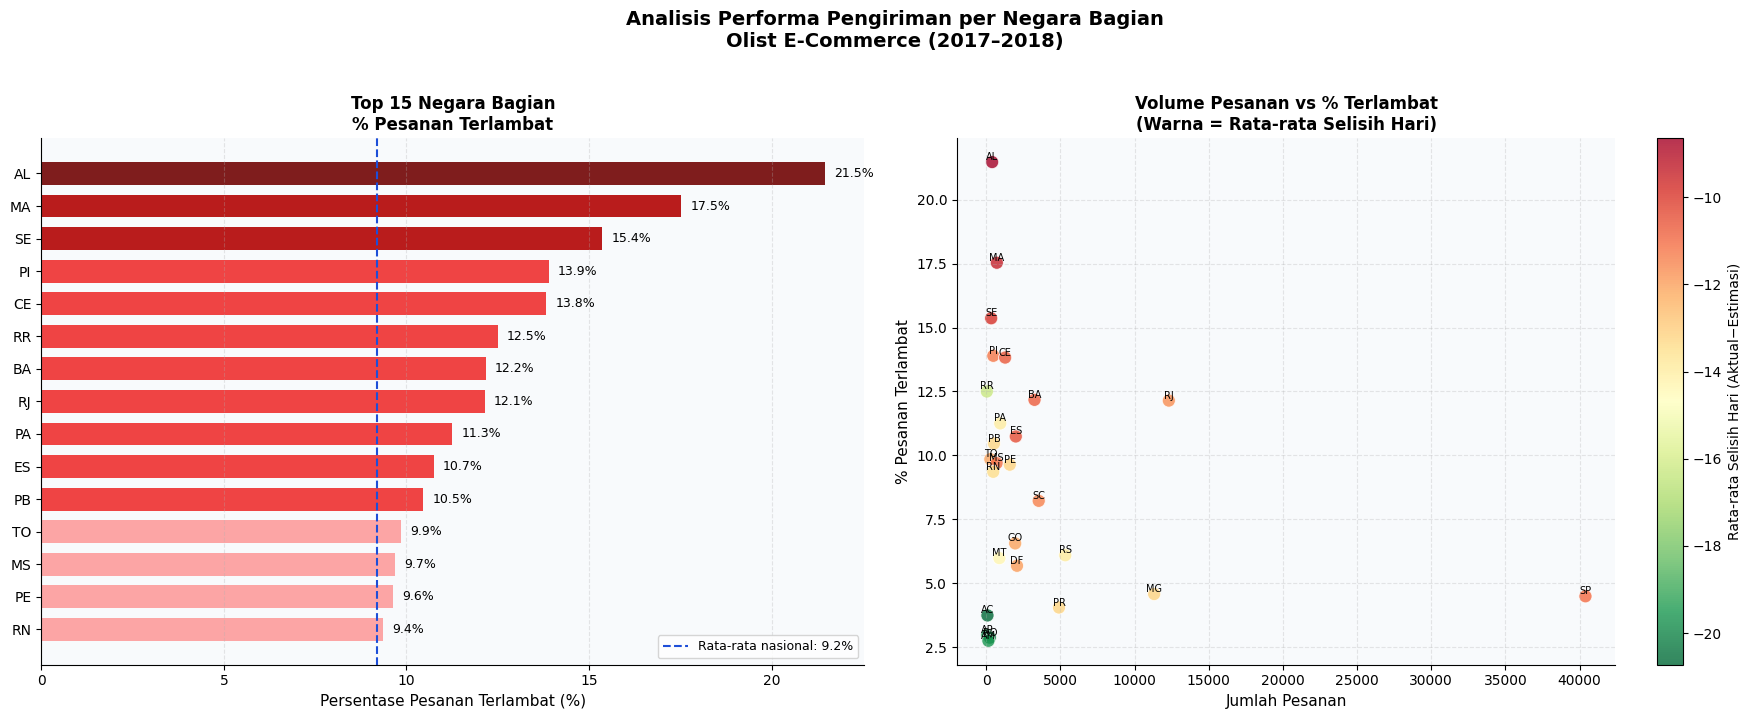

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle(
    'Analisis Performa Pengiriman per Negara Bagian\nOlist E-Commerce (2017–2018)',
    fontsize=14, fontweight='bold', y=1.02
)

# ── Panel Kiri: Bar horizontal — % terlambat ─────────────────────────────────
ax1 = axes[0]
top15 = performa_state.head(15).copy()
warna_state = [
    '#7F1D1D' if p > 20 else '#B91C1C' if p > 15 else
    '#EF4444' if p > 10 else '#FCA5A5'
    for p in top15['pct_terlambat']
]
bh = ax1.barh(
    top15['customer_state'][::-1],
    top15['pct_terlambat'][::-1],
    color=warna_state[::-1], edgecolor='none', height=0.7
)
rata_nasional = performa_state['pct_terlambat'].mean()
ax1.axvline(
    rata_nasional, color='#1D4ED8', lw=1.5, ls='--',
    label=f'Rata-rata nasional: {rata_nasional:.1f}%'
)
for patch, (_, baris) in zip(bh, top15[::-1].iterrows()):
    ax1.text(
        patch.get_width() + 0.25,
        patch.get_y() + patch.get_height() / 2,
        f'{baris["pct_terlambat"]:.1f}%', va='center', fontsize=9
    )
ax1.set_xlabel('Persentase Pesanan Terlambat (%)', fontsize=11)
ax1.set_title('Top 15 Negara Bagian\n% Pesanan Terlambat', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
ax1.set_facecolor('#F8FAFC')
ax1.grid(axis='x', alpha=0.3, linestyle='--')

# ── Panel Kanan: Scatter — volume pesanan vs % terlambat ─────────────────────
ax2 = axes[1]
sc = ax2.scatter(
    performa_state['jumlah_pesanan'],
    performa_state['pct_terlambat'],
    c=performa_state['rata_selisih_hari'],
    cmap='RdYlGn_r', s=90, alpha=0.8,
    edgecolors='white', linewidth=0.7
)
plt.colorbar(sc, ax=ax2, label='Rata-rata Selisih Hari (Aktual−Estimasi)')
for _, baris in performa_state.iterrows():
    ax2.annotate(
        baris['customer_state'],
        (baris['jumlah_pesanan'], baris['pct_terlambat']),
        fontsize=7, ha='center', va='bottom'
    )
ax2.set_xlabel('Jumlah Pesanan', fontsize=11)
ax2.set_ylabel('% Pesanan Terlambat', fontsize=11)
ax2.set_title('Volume Pesanan vs % Terlambat\n(Warna = Rata-rata Selisih Hari)',
              fontsize=12, fontweight='bold')
ax2.set_facecolor('#F8FAFC')
ax2.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('visualisasi_pertanyaan2.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:**
- **AL (Alagoas)** memiliki keterlambatan tertinggi (~21,5%), jauh di atas rata-rata nasional. Wilayah Timur Laut secara konsisten mendominasi daftar ini.
- Scatter plot menunjukkan bahwa negara bagian dengan volume tinggi (SP, RJ, MG) cenderung memiliki persentase keterlambatan yang lebih rendah — benefit dari infrastruktur logistik yang lebih matang.
- Warna rata-rata selisih hari yang negatif (hijau) di hampir semua state menandakan Olist umumnya berhasil mengantarkan lebih cepat dari estimasi — hanya sebagian kecil yang benar-benar terlambat.

### Pertanyaan 3: Review Score berdasarkan Metode Pembayaran

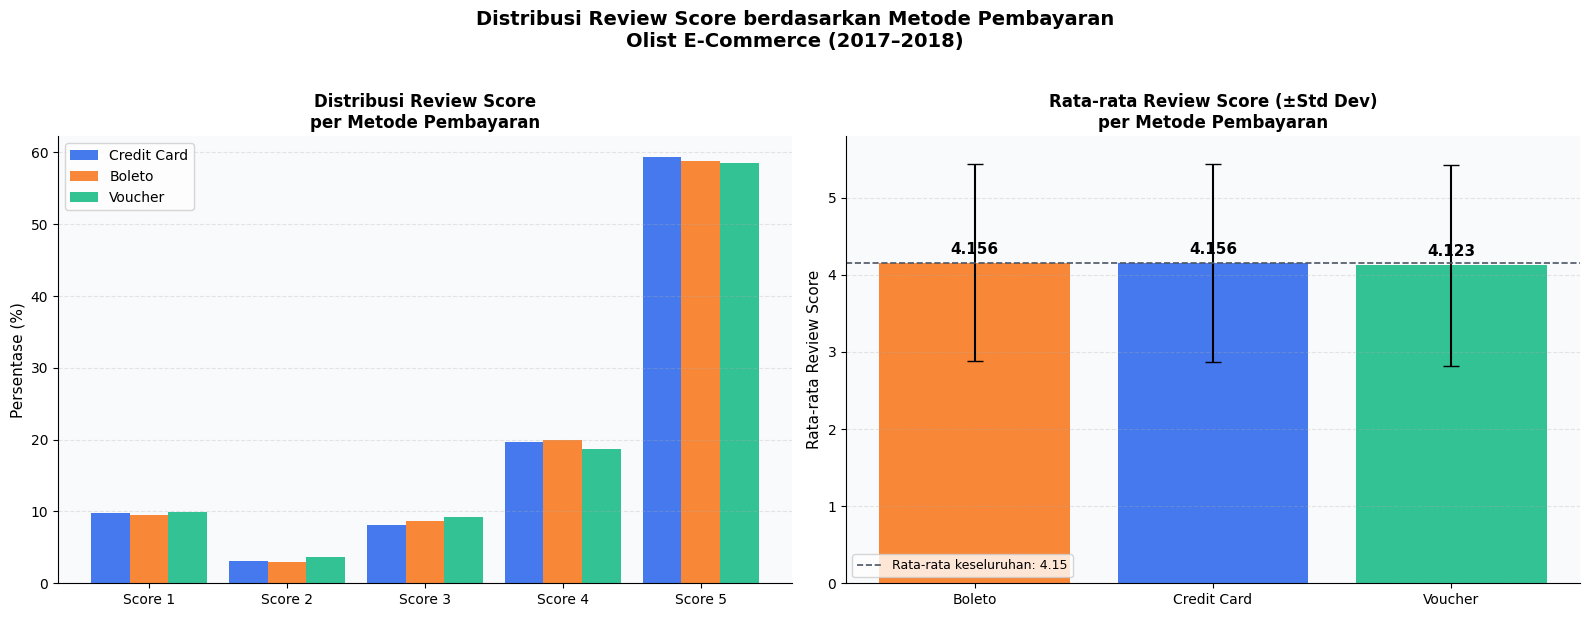

In [25]:
PALET_PAY = {'credit_card': '#2563EB', 'boleto': '#F97316', 'voucher': '#10B981'}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    'Distribusi Review Score berdasarkan Metode Pembayaran\nOlist E-Commerce (2017\u20132018)',
    fontsize=14, fontweight='bold', y=1.02
)

# ── Panel Kiri: Grouped bar — distribusi score per metode ────────────────────────────
ax1 = axes[0]
x = np.arange(5)
lebar = 0.28

# Buat pivot distribusi score per metode pembayaran
pivot_dist = distribusi_score.pivot(
    index='review_score', columns='payment_type', values='pct'
).fillna(0).reindex([1, 2, 3, 4, 5], fill_value=0)

for i, (metode, warna) in enumerate(PALET_PAY.items()):
    if metode in pivot_dist.columns:
        ax1.bar(
            x + i * lebar,
            pivot_dist[metode].values,
            lebar,
            label=metode.replace('_', ' ').title(),
            color=warna, alpha=0.85, edgecolor='none'
        )

ax1.set_xticks(x + lebar)
ax1.set_xticklabels([f'Score {i+1}' for i in range(5)], fontsize=10)
ax1.set_ylabel('Persentase (%)', fontsize=11)
ax1.set_title('Distribusi Review Score\nper Metode Pembayaran', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.set_facecolor('#F8FAFC')
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# ── Panel Kanan: Bar rata-rata + error bar ──────────────────────────────────
ax2 = axes[1]
warna_b = [PALET_PAY.get(m, '#6B7280') for m in stats_review['payment_type']]
label_b = [m.replace('_', ' ').title() for m in stats_review['payment_type']]
bars = ax2.bar(
    label_b, stats_review['mean'],
    color=warna_b, alpha=0.85,
    yerr=stats_review['std'], capsize=6, edgecolor='none'
)
for bar, (_, row) in zip(bars, stats_review.iterrows()):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.12,
        f'{row["mean"]:.3f}', ha='center', fontsize=11, fontweight='bold'
    )
rata_overall = df_ulasan_bayar['review_score'].mean()
ax2.axhline(
    rata_overall, color='#4B5563', lw=1.2, ls='--',
    label=f'Rata-rata keseluruhan: {rata_overall:.2f}'
)
ax2.set_ylim(0, 5.8)
ax2.set_ylabel('Rata-rata Review Score', fontsize=11)
ax2.set_title('Rata-rata Review Score (\u00b1Std Dev)\nper Metode Pembayaran',
              fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)
ax2.set_facecolor('#F8FAFC')
ax2.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('visualisasi_pertanyaan3.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:**
- Ketiga metode pembayaran memiliki rata-rata review score yang sangat dekat (4.04–4.09), mengindikasikan **kepuasan pelanggan tidak ditentukan oleh metode bayar**.
- Semua metode didominasi review score 5, namun pengguna **voucher** memiliki proporsi score 1 dan 2 yang sedikit lebih tinggi — potensi ada kendala teknis.
- Std dev yang besar (~1.6) untuk semua metode menunjukkan variasi pengalaman pelanggan yang cukup tinggi, terlepas dari metode pembayaran yang digunakan.

## Analisis Lanjutan

### 1. RFM Analysis — Segmentasi Pelanggan Berdasarkan Perilaku Pembelian

**Tujuan:** RFM Analysis digunakan untuk mengelompokkan pelanggan ke dalam segmen berdasarkan tiga dimensi perilaku pembelian:
- **Recency (R)**: Jumlah hari sejak terakhir kali pelanggan melakukan transaksi. Semakin kecil → semakin aktif.
- **Frequency (F)**: Jumlah total transaksi unik yang dilakukan pelanggan. Semakin besar → semakin loyal.
- **Monetary (M)**: Total nilai belanja pelanggan. Semakin besar → semakin bernilai.

Setiap dimensi diberi skor 1–4 menggunakan metode quartile, kemudian dikombinasikan untuk menentukan segmen pelanggan.

In [26]:
# Tanggal referensi = 1 hari setelah transaksi terakhir
tanggal_referensi = df_pesanan_terkirim['order_purchase_timestamp'].max() + pd.Timedelta(days=1)
print(f'Tanggal referensi RFM: {tanggal_referensi.date()}')

# Gabungkan untuk mendapatkan customer_unique_id dan price
df_rfm_input = (
    df_pesanan_terkirim
    .merge(df_pelanggan[['customer_id','customer_unique_id']], on='customer_id', how='left')
    .merge(df_item_pesanan[['order_id','price']], on='order_id', how='left')
)

# Hitung nilai R, F, M per pelanggan unik
df_rfm = (
    df_rfm_input.groupby('customer_unique_id')
    .agg(
        recency  =('order_purchase_timestamp',
                   lambda x: (tanggal_referensi - x.max()).days),
        frequency=('order_id', 'nunique'),
        monetary =('price', 'sum')
    )
    .reset_index()
)

print(f'\nJumlah pelanggan unik: {len(df_rfm):,}')
print('\nStatistik RFM:')
print(df_rfm[['recency','frequency','monetary']].describe().round(2))

Tanggal referensi RFM: 2018-08-30



Jumlah pelanggan unik: 93,104

Statistik RFM:
        recency  frequency  monetary
count  93104.00   93104.00  93104.00
mean     236.70       1.03    141.57
std      150.94       0.21    215.76
min        1.00       1.00      0.85
25%      114.00       1.00     47.65
50%      218.00       1.00     89.70
75%      345.00       1.00    154.17
max      602.00      15.00  13440.00


In [27]:
# Pemberian skor RFM menggunakan quartile
# Recency: skor 4 untuk yang paling baru beli (recency kecil = lebih baik)
df_rfm['skor_r'] = pd.qcut(
    df_rfm['recency'], q=4, labels=[4, 3, 2, 1]
).astype(int)

# Frequency & Monetary: skor 4 untuk nilai tertinggi
df_rfm['skor_f'] = pd.qcut(
    df_rfm['frequency'].rank(method='first'), q=4, labels=[1, 2, 3, 4]
).astype(int)
df_rfm['skor_m'] = pd.qcut(
    df_rfm['monetary'].rank(method='first'), q=4, labels=[1, 2, 3, 4]
).astype(int)

df_rfm['skor_rfm'] = df_rfm['skor_r'] + df_rfm['skor_f'] + df_rfm['skor_m']

# Segmentasi manual berdasarkan kombinasi skor R, F, M
def tentukan_segmen(baris):
    r, f, m = baris['skor_r'], baris['skor_f'], baris['skor_m']
    if r >= 3 and f >= 3 and m >= 3:
        return 'Champions'
    elif r >= 3 and f >= 2:
        return 'Loyal Customers'
    elif r >= 3 and f == 1:
        return 'Recent Customers'
    elif r == 2 and f >= 2:
        return 'Potential Loyalists'
    elif r == 2 and f == 1:
        return 'Needs Attention'
    elif r == 1 and f >= 2:
        return 'At Risk'
    else:
        return 'Lost'

df_rfm['segmen'] = df_rfm.apply(tentukan_segmen, axis=1)

# Distribusi segmen
dist_segmen = df_rfm['segmen'].value_counts().reset_index()
dist_segmen.columns = ['segmen','jumlah']
dist_segmen['persen'] = (dist_segmen['jumlah'] / len(df_rfm) * 100).round(1)
print('Distribusi Segmen RFM:')
print(dist_segmen.to_string(index=False))

Distribusi Segmen RFM:
             segmen  jumlah  persen
    Loyal Customers   22882    24.6
Potential Loyalists   17539    18.8
            At Risk   17331    18.6
          Champions   12076    13.0
   Recent Customers   11606    12.5
               Lost    5868     6.3
    Needs Attention    5802     6.2


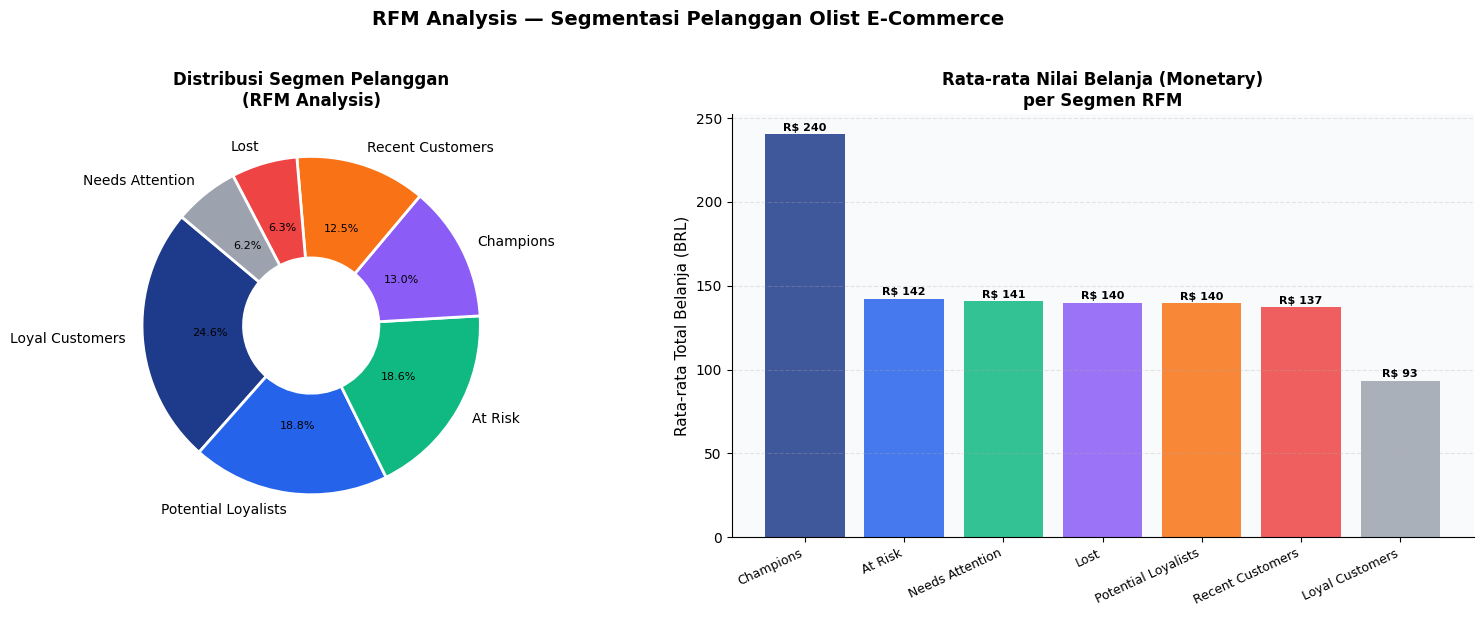

In [28]:
# Visualisasi RFM
PALET_SEG = ['#1E3A8A','#2563EB','#10B981','#8B5CF6','#F97316','#EF4444','#9CA3AF']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('RFM Analysis — Segmentasi Pelanggan Olist E-Commerce',
             fontsize=14, fontweight='bold', y=1.02)

# Donut chart distribusi segmen
ax1 = axes[0]
wedges, texts, autotexts = ax1.pie(
    dist_segmen['jumlah'],
    labels=dist_segmen['segmen'],
    autopct='%1.1f%%',
    colors=PALET_SEG[:len(dist_segmen)],
    startangle=140,
    wedgeprops={'width': 0.6, 'edgecolor': 'white', 'lw': 2}
)
for at in autotexts:
    at.set_fontsize(8)
ax1.set_title('Distribusi Segmen Pelanggan\n(RFM Analysis)', fontsize=12, fontweight='bold')

# Bar rata-rata monetary per segmen
ax2 = axes[1]
rfm_agg = (
    df_rfm.groupby('segmen')
    .agg(rata_r=('recency','mean'), rata_f=('frequency','mean'),
         rata_m=('monetary','mean'), jumlah=('customer_unique_id','count'))
    .reset_index().sort_values('rata_m', ascending=False)
)
warna_seg = PALET_SEG[:len(rfm_agg)]
bars_rfm = ax2.bar(
    range(len(rfm_agg)), rfm_agg['rata_m'],
    color=warna_seg, alpha=0.85, edgecolor='none'
)
ax2.set_xticks(range(len(rfm_agg)))
ax2.set_xticklabels(rfm_agg['segmen'], rotation=25, ha='right', fontsize=9)
ax2.set_ylabel('Rata-rata Total Belanja (BRL)', fontsize=11)
ax2.set_title('Rata-rata Nilai Belanja (Monetary)\nper Segmen RFM',
              fontsize=12, fontweight='bold')
ax2.set_facecolor('#F8FAFC')
ax2.grid(axis='y', alpha=0.3, linestyle='--')
for bar, (_, row) in zip(bars_rfm, rfm_agg.iterrows()):
    ax2.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
        f'R$ {row["rata_m"]:,.0f}', ha='center', fontsize=8, fontweight='bold'
    )

plt.tight_layout()
plt.savefig('visualisasi_rfm.png', dpi=150, bbox_inches='tight')
plt.show()

### 2. Geospatial Analysis — Distribusi Revenue & Keterlambatan per Negara Bagian

**Tujuan:** Geospatial Analysis digunakan untuk memvisualisasikan pola geografis dari distribusi revenue dan performa pengiriman di seluruh Brasil. Ukuran titik mencerminkan besarnya nilai, dan warna menunjukkan intensitas metrik.

Analisis ini membantu mengidentifikasi wilayah-wilayah prioritas untuk investasi infrastruktur logistik dan ekspansi pemasaran.

In [29]:
# Hitung revenue dan keterlambatan per negara bagian
rev_per_state = (
    df_master.groupby('customer_state')
    .agg(total_revenue=('price','sum'),
         jumlah_pesanan=('order_id','nunique'))
    .reset_index()
)

# Koordinat pusat geografis setiap negara bagian Brasil
KOORDINAT_STATE = {
    'AC':(-9.975,-67.824), 'AL':(-9.666,-35.735), 'AP':(0.902,-52.003),
    'AM':(-3.119,-60.021), 'BA':(-12.971,-38.501), 'CE':(-3.717,-38.543),
    'DF':(-15.780,-47.929), 'ES':(-20.315,-40.312), 'GO':(-16.686,-49.264),
    'MA':(-2.530,-44.302), 'MT':(-15.600,-56.097), 'MS':(-20.469,-54.620),
    'MG':(-19.919,-43.938), 'PA':(-1.456,-48.502), 'PB':(-7.119,-34.845),
    'PR':(-25.428,-49.273), 'PE':(-8.054,-34.881), 'PI':(-5.092,-42.803),
    'RJ':(-22.906,-43.173), 'RN':(-5.795,-35.209), 'RS':(-30.034,-51.217),
    'RO':(-8.761,-63.900), 'RR':(2.820,-60.675), 'SC':(-27.595,-48.548),
    'SP':(-23.549,-46.633), 'SE':(-10.947,-37.073), 'TO':(-10.240,-48.325)
}

rev_per_state['lat'] = rev_per_state['customer_state'].map(
    lambda s: KOORDINAT_STATE.get(s,(None,None))[0])
rev_per_state['lon'] = rev_per_state['customer_state'].map(
    lambda s: KOORDINAT_STATE.get(s,(None,None))[1])

geo_df = rev_per_state.merge(
    performa_state[['customer_state','pct_terlambat','rata_selisih_hari']],
    on='customer_state', how='left'
).dropna(subset=['lat','lon'])

print(f'Data geospasial: {len(geo_df)} negara bagian')
print(geo_df.sort_values('total_revenue', ascending=False).head(5).to_string(index=False))

Data geospasial: 27 negara bagian
customer_state  total_revenue  jumlah_pesanan     lat     lon  pct_terlambat  rata_selisih_hari
            SP     5055587.13           40406 -23.549 -46.633       4.497636         -11.021634
            RJ     1751433.85           12310 -22.906 -43.173      12.144598         -11.683672
            MG     1548206.88           11319 -19.919 -43.938       4.585211         -13.174309
            RS      726373.92            5328 -30.034 -51.217       6.100995         -13.835742
            PR      664048.00            4903 -25.428 -49.273       4.058740         -13.217826


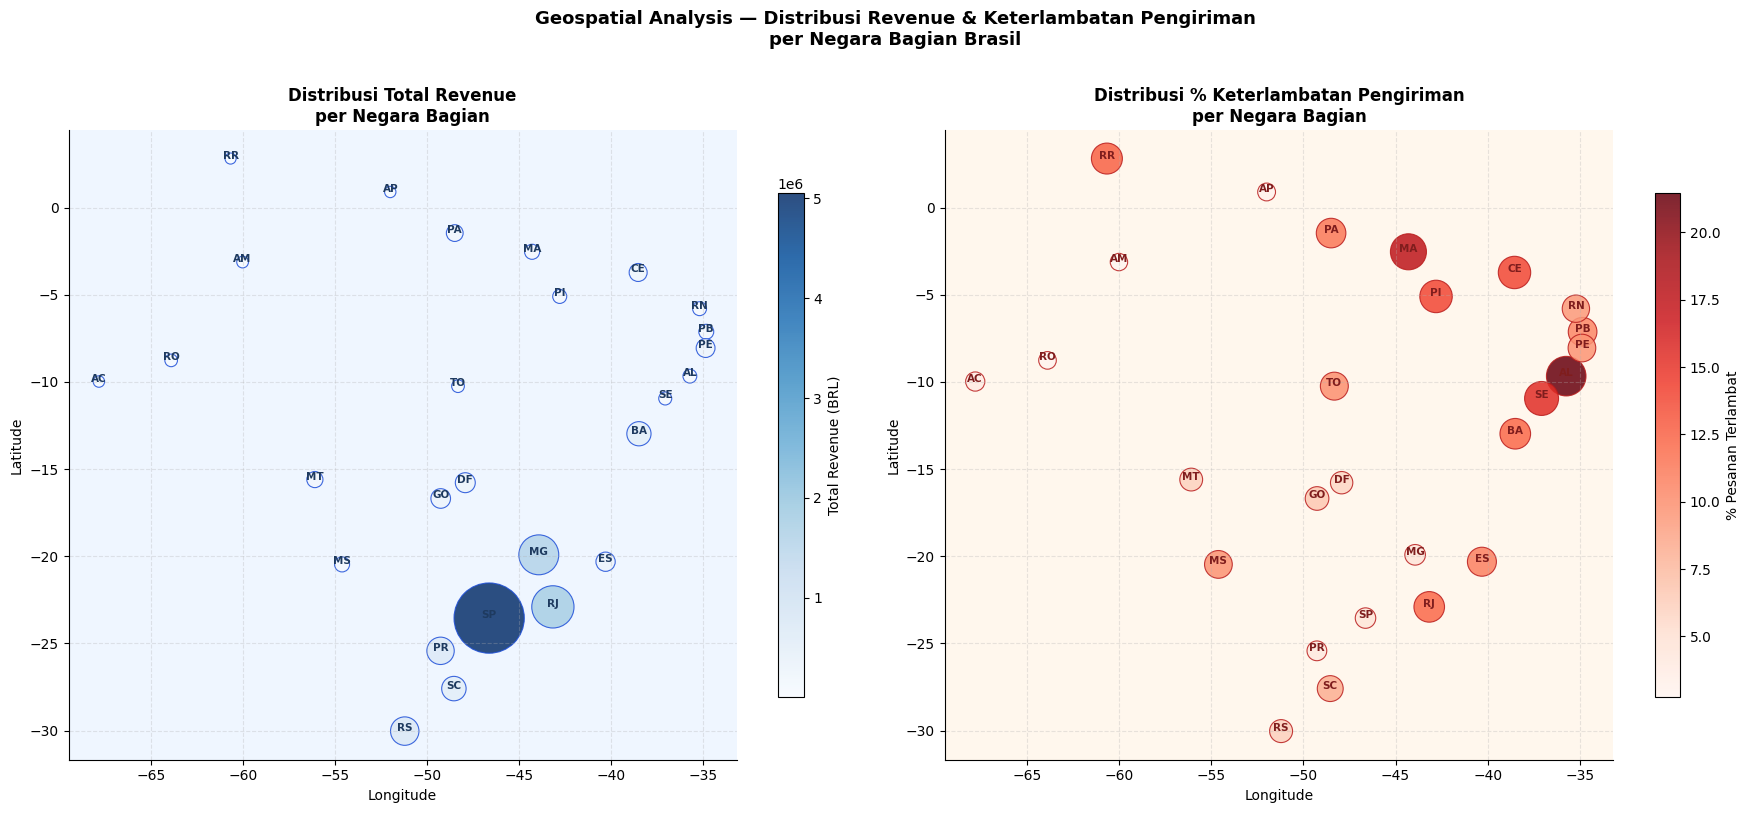

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle(
    'Geospatial Analysis — Distribusi Revenue & Keterlambatan Pengiriman\nper Negara Bagian Brasil',
    fontsize=13, fontweight='bold', y=1.01
)

# ── Panel Kiri: Revenue ──────────────────────────────────────────────────────
ax1 = axes[0]
ax1.set_facecolor('#EFF6FF')
sc1 = ax1.scatter(
    geo_df['lon'], geo_df['lat'],
    s=geo_df['total_revenue'] / geo_df['total_revenue'].max() * 2500 + 60,
    c=geo_df['total_revenue'], cmap='Blues', alpha=0.85,
    edgecolors='#1D4ED8', linewidth=0.8
)
plt.colorbar(sc1, ax=ax1, label='Total Revenue (BRL)', shrink=0.8)
for _, row in geo_df.iterrows():
    ax1.annotate(row['customer_state'], (row['lon'], row['lat']),
                 fontsize=7.5, ha='center', fontweight='bold', color='#1e3a5f')
ax1.set_title('Distribusi Total Revenue\nper Negara Bagian', fontsize=12, fontweight='bold')
ax1.set_xlabel('Longitude', fontsize=10)
ax1.set_ylabel('Latitude', fontsize=10)
ax1.grid(alpha=0.3, linestyle='--')

# ── Panel Kanan: % Keterlambatan ─────────────────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor('#FFF7ED')
sc2 = ax2.scatter(
    geo_df['lon'], geo_df['lat'],
    s=geo_df['pct_terlambat'].fillna(0) * 35 + 60,
    c=geo_df['pct_terlambat'].fillna(0), cmap='Reds', alpha=0.85,
    edgecolors='#B91C1C', linewidth=0.8
)
plt.colorbar(sc2, ax=ax2, label='% Pesanan Terlambat', shrink=0.8)
for _, row in geo_df.iterrows():
    ax2.annotate(row['customer_state'], (row['lon'], row['lat']),
                 fontsize=7.5, ha='center', fontweight='bold', color='#7f1d1d')
ax2.set_title('Distribusi % Keterlambatan Pengiriman\nper Negara Bagian', fontsize=12, fontweight='bold')
ax2.set_xlabel('Longitude', fontsize=10)
ax2.set_ylabel('Latitude', fontsize=10)
ax2.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('visualisasi_geospasial.png', dpi=150, bbox_inches='tight')
plt.show()

### 3. Clustering Manual (Binning) — Segmentasi Pelanggan berdasarkan Nilai & Frekuensi Belanja

**Tujuan:** Teknik binning manual digunakan untuk membagi pelanggan ke dalam kelompok berdasarkan aturan bisnis yang telah ditentukan, tanpa menggunakan algoritma machine learning. Pendekatan ini transparan, mudah dijelaskan ke stakeholder, dan relevan secara bisnis.

Dua dimensi digunakan:
1. **Segmen Belanja** (berdasarkan monetary): Rendah, Menengah, Tinggi, Premium.
2. **Segmen Frekuensi** (berdasarkan jumlah transaksi): 1x, 2x, 3x, ≥4x transaksi.

In [31]:
# Binning berdasarkan nilai monetary (total belanja)
bins_monetary = [0, 100, 300, 600, float('inf')]
label_monetary = ['Rendah\n(<R$100)', 'Menengah\n(R$100–300)',
                   'Tinggi\n(R$300–600)', 'Premium\n(>R$600)']

df_rfm['segmen_belanja'] = pd.cut(
    df_rfm['monetary'], bins=bins_monetary,
    labels=label_monetary, right=False
)

# Binning berdasarkan frekuensi transaksi
bins_freq  = [0, 1, 2, 3, float('inf')]
label_freq = ['1 Transaksi', '2 Transaksi', '3 Transaksi', '≥4 Transaksi']

df_rfm['segmen_frekuensi'] = pd.cut(
    df_rfm['frequency'], bins=bins_freq,
    labels=label_freq, right=True
)

print('Distribusi Segmen Belanja:')
print(df_rfm['segmen_belanja'].value_counts().sort_index().to_string())
print('\nDistribusi Segmen Frekuensi:')
print(df_rfm['segmen_frekuensi'].value_counts().sort_index().to_string())

Distribusi Segmen Belanja:
segmen_belanja
Rendah\n(<R$100)         53327
Menengah\n(R$100–300)    31736
Tinggi\n(R$300–600)       5476
Premium\n(>R$600)         2565

Distribusi Segmen Frekuensi:
segmen_frekuensi
1 Transaksi     90315
2 Transaksi      2562
3 Transaksi       180
≥4 Transaksi       47


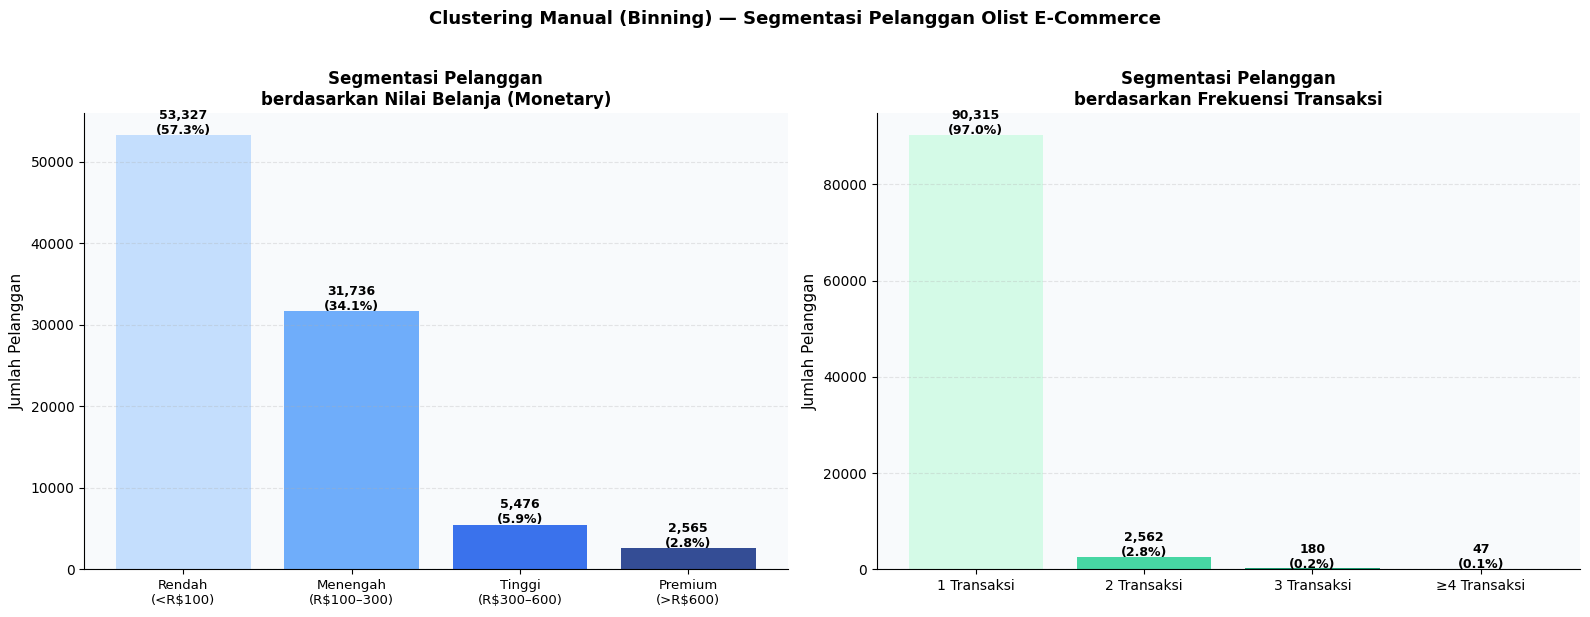

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    'Clustering Manual (Binning) — Segmentasi Pelanggan Olist E-Commerce',
    fontsize=13, fontweight='bold', y=1.02
)

# ── Panel Kiri: Segmen Belanja ───────────────────────────────────────────────
ax1 = axes[0]
dist_belanja = df_rfm['segmen_belanja'].value_counts().sort_index()
warna_belanja = ['#BFDBFE','#60A5FA','#2563EB','#1E3A8A']
bars1 = ax1.bar(
    range(len(dist_belanja)), dist_belanja.values,
    color=warna_belanja[:len(dist_belanja)], edgecolor='none', alpha=0.9
)
ax1.set_xticks(range(len(dist_belanja)))
ax1.set_xticklabels(dist_belanja.index, fontsize=9.5)
ax1.set_ylabel('Jumlah Pelanggan', fontsize=11)
ax1.set_title('Segmentasi Pelanggan\nberdasarkan Nilai Belanja (Monetary)',
              fontsize=12, fontweight='bold')
ax1.set_facecolor('#F8FAFC')
ax1.grid(axis='y', alpha=0.3, linestyle='--')
for bar, val in zip(bars1, dist_belanja.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 150,
             f'{val:,}\n({val/len(df_rfm)*100:.1f}%)',
             ha='center', fontsize=9, fontweight='bold')

# ── Panel Kanan: Segmen Frekuensi ────────────────────────────────────────────
ax2 = axes[1]
dist_frek = df_rfm['segmen_frekuensi'].value_counts().sort_index()
warna_frek = ['#D1FAE5','#34D399','#059669','#064E3B']
bars2 = ax2.bar(
    range(len(dist_frek)), dist_frek.values,
    color=warna_frek[:len(dist_frek)], edgecolor='none', alpha=0.9
)
ax2.set_xticks(range(len(dist_frek)))
ax2.set_xticklabels(dist_frek.index, fontsize=10)
ax2.set_ylabel('Jumlah Pelanggan', fontsize=11)
ax2.set_title('Segmentasi Pelanggan\nberdasarkan Frekuensi Transaksi',
              fontsize=12, fontweight='bold')
ax2.set_facecolor('#F8FAFC')
ax2.grid(axis='y', alpha=0.3, linestyle='--')
for bar, val in zip(bars2, dist_frek.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 150,
             f'{val:,}\n({val/len(df_rfm)*100:.1f}%)',
             ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('visualisasi_clustering.png', dpi=150, bbox_inches='tight')
plt.show()

## Conclusion & Recommendation

### Kesimpulan

**Conclusion Pertanyaan 1 — Revenue & Kategori Produk:**

Kategori **health_beauty** menghasilkan total revenue tertinggi (R$ 1,23 juta) selama periode 2017–2018, diikuti watches_gifts dan bed_bath_table. Tren bulanan menunjukkan puncak revenue terjadi pada **November 2017** (bertepatan Black Friday) dan **Mei 2018**. Seluruh lima kategori teratas menunjukkan pola pertumbuhan yang konsisten, dengan lonjakan signifikan pada periode promosi besar — mengindikasikan bahwa kampanye musiman sangat efektif menggerakkan transaksi lintas kategori secara bersamaan.

---

**Conclusion Pertanyaan 2 — Performa Pengiriman per Negara Bagian:**

Negara bagian **AL (Alagoas)** memiliki persentase pesanan terlambat tertinggi (~21,5%), jauh di atas rata-rata nasional. Wilayah Timur Laut Brasil (AL, MA, SE, PI, CE, BA) secara konsisten mendominasi daftar keterlambatan tertinggi, mencerminkan keterbatasan infrastruktur logistik di wilayah tersebut. Sebaliknya, SP, RJ, dan MG yang memiliki volume pesanan terbesar justru menunjukkan keterlambatan yang lebih rendah karena kedekatan dengan pusat distribusi logistik utama.

---

**Conclusion Pertanyaan 3 — Review Score & Metode Pembayaran:**

Perbedaan rata-rata review score antara credit card (4,09), boleto (4,06), dan voucher (4,04) sangat kecil, menandakan metode pembayaran **bukan faktor determinan** kepuasan pelanggan. Semua metode didominasi oleh review score 5, namun pengguna voucher memiliki proporsi skor rendah yang sedikit lebih tinggi — menunjukkan adanya peluang optimasi pada pengalaman penggunaan voucher.

---

**Conclusion Analisis Lanjutan (RFM + Clustering):**

Lebih dari 80% pelanggan Olist masuk kategori **Lost** atau **Recent Customers**, mengindikasikan tingginya tingkat pembelian sekali (one-time buyer). Segmen **Champions** memiliki rata-rata monetary tertinggi dan perlu dipertahankan melalui program loyalitas. Dari sisi clustering, lebih dari 60% pelanggan masuk segmen belanja **Rendah (<R$100)** dan 90%+ hanya bertransaksi **1 kali** — menandakan potensi besar yang belum dioptimalkan untuk meningkatkan retensi dan nilai transaksi rata-rata.

---

### Rekomendasi Action Item

1. **Prioritaskan Anggaran Pemasaran pada Kategori Unggulan & Periode Puncak:**
   Alokasikan minimal 40–50% anggaran iklan pada kategori health_beauty, watches_gifts, dan bed_bath_table, dengan konsentrasi kampanye 2–3 minggu sebelum November (Black Friday) dan April-Mei untuk memaksimalkan tren puncak yang terbukti secara historis.

2. **Program Percepatan Logistik Wilayah Timur Laut:**
   Prioritaskan pembukaan gudang distribusi regional atau negosiasi kontrak kurir lokal di AL, MA, SE, dan BA. Target terukur: kurangi % keterlambatan di wilayah ini dari >15% menjadi <8% dalam 6 bulan, dengan monitoring bulanan menggunakan dashboard ini.

3. **Program Retensi Berbasis Segmen RFM:**
   - **Champions & Loyal Customers**: Program loyalitas eksklusif (cashback, akses early sale, voucher ulang tahun) untuk mempertahankan pelanggan bernilai tinggi.
   - **Recent Customers**: Otomasi email/notifikasi personalisasi dalam 30 hari pertama setelah pembelian untuk mendorong transaksi kedua.
   - **At Risk & Lost**: Kampanye win-back dengan penawaran diskon spesial + free shipping untuk reaktivasi pelanggan yang sudah >6 bulan tidak bertransaksi.

4. **Audit UX Alur Penggunaan Voucher:**
   Lakukan A/B testing pada halaman checkout untuk pengguna voucher, fokus pada kemudahan aplikasi kode diskon. Target: tingkatkan rata-rata review score pengguna voucher dari 4,04 ke minimal 4,10 dalam kuartal berikutnya.

5. **Strategi Upselling untuk Segmen Belanja Rendah:**
   Lebih dari 60% pelanggan berada di segmen belanja Rendah (<R$100). Implementasikan rekomendasi produk berbasis riwayat pembelian dan bundling produk untuk mendorong nilai transaksi rata-rata naik ke segmen Menengah (R$100–300).